### Evaluating generative text models

In [1]:
import torch
from IPython.core.pylabtools import figsize
from llmArchitecture import GPTModel
from sympy.printing.pytorch import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

#### Utility functions for text to token ID conversion

In [2]:
import tiktoken
from llmArchitecture import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


#### Calculating the text generation loss

In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
               [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]

with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [4]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [5]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: " +
      f"{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [6]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [7]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [8]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [9]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [10]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [11]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [12]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [13]:
file_path = "../data/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Total characters:", total_characters)
print("Total tokens:", total_tokens)

Total characters: 21877
Total tokens: 5537


In [14]:
train_ratio = 0.90
split_idx = int(train_ratio * total_characters)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]
print("train_data:", len(train_data))
print("val_data:", len(val_data))

train_data: 19689
val_data: 2188


In [15]:
from dataloader import create_dataloader_v1

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    shuffle=True,
    drop_last=True,
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    shuffle=False,
    drop_last=False,
)

In [16]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [17]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten())
    return loss

####  Function to compute the training and validation loss

In [18]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss
        else:
            break
    return total_loss / num_batches

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: tensor(10.9862, device='cuda:0')
Validation loss: tensor(11.0055, device='cuda:0')


#### The main function for pretraining LLMs

In [20]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表，用于记录训练损失、验证损失和已处理的token数量
    train_losses, val_losses, track_tokens_seen = [], [], []
    # 初始化已处理token总数和全局训练步数
    tokens_seen, global_step = 0, -1

    # 主训练循环，遍历所有训练轮次（epoch）
    for epoch in range(num_epochs):
        # 将模型设置为训练模式（启用dropout、batch norm等训练专属层）
        model.train()
        # 遍历训练数据集中的每一个批次
        for input_batch, target_batch in train_loader:
            # 清空优化器中累积的梯度，避免上一批次的梯度影响当前批次
            optimizer.zero_grad()
            # 计算当前批次的损失值
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            # 反向传播，计算损失对模型参数的梯度
            loss.backward()
            # 根据梯度更新模型的可训练参数（权重）
            optimizer.step()
            # 累加当前批次处理的token总数（input_batch.numel()返回张量元素总数）
            tokens_seen += input_batch.numel()
            # 全局训练步数+1
            global_step += 1

            # 每经过eval_freq步，执行一次模型评估（可选的评估步骤）
            if global_step % eval_freq == 0:
                # 调用评估函数，计算训练集和验证集的损失
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                # 将训练损失、验证损失、已处理token数记录到对应列表
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                # 打印当前训练进度：轮次、步数、训练损失、验证损失
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # 每完成一个epoch，生成并打印一段示例文本，直观观察模型生成效果
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    # 训练结束后，返回记录的训练损失、验证损失和已处理token数
    return train_losses, val_losses, track_tokens_seen

In [21]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # 将模型切换为评估模式：禁用Dropout、BatchNorm等训练专属层，保证评估结果稳定可复现
    model.eval()
    # 禁用梯度计算：评估阶段不需要反向传播，关闭梯度可大幅减少内存占用、提升计算速度
    with torch.no_grad():
        # 计算训练集上的平均损失（仅计算eval_iter个批次，避免全量计算耗时过长）
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        ).cpu().item()
        # 计算验证集上的平均损失（同样仅计算eval_iter个批次）
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        ).cpu().item()
    # 评估完成后，将模型切回训练模式，恢复Dropout等层，不影响后续训练
    model.train()
    # 返回训练集损失和验证集损失，用于监控模型过拟合情况
    return train_loss, val_loss

In [22]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    # 将模型切换为评估模式：禁用Dropout等训练专属层，保证生成结果稳定
    model.eval()

    # 从模型的位置嵌入层获取上下文窗口大小（即模型支持的最大输入token数）
    context_size = model.pos_emb.weight.shape[0]

    # 将起始文本编码为token ID张量，并移动到指定计算设备（CPU/GPU）
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    # 禁用梯度计算：文本生成不需要反向传播，关闭梯度可节省显存、提升速度
    with torch.no_grad():
        # 调用文本生成函数，基于起始上下文生成最多50个新token
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )

    # 将生成的token ID张量解码回人类可读的文本
    decoded_text = token_ids_to_text(token_ids, tokenizer)

    # 打印生成的文本，将换行符替换为空格，实现紧凑的单行打印格式
    print(decoded_text.replace("\n", " "))

    # 生成完成后，将模型切回训练模式，不影响后续训练流程
    model.train()

In [23]:
# 固定PyTorch随机种子，确保实验可复现（每次运行初始化权重、数据采样完全一致）
torch.manual_seed(123)

# 实例化GPT模型，使用1.24亿参数的配置（GPT_CONFIG_124M）
model = GPTModel(GPT_CONFIG_124M)

# 将模型移动到指定计算设备（CPU/GPU，如cuda:0），后续所有张量运算都在该设备上执行
model.to(device)

# 初始化AdamW优化器：
# - model.parameters()：获取模型所有可训练的权重参数
# - lr=0.0004：学习率，控制参数更新步长
# - weight_decay=0.1：权重衰减（L2正则化），防止模型过拟合
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)

# 设置训练总轮次（epoch）为10轮
num_epochs = 10

# 调用训练函数，启动模型训练
# 函数返回训练损失、验证损失、已处理token数三个列表，用于后续可视化分析
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,  # 训练总轮次
    eval_freq=5,            # 每5个训练步执行一次模型评估
    eval_iter=5,            # 每次评估时，仅计算5个批次的损失（加速评估）
    start_context="Every effort moves you",  # 文本生成的起始提示词
    tokenizer=tokenizer     # 分词器，用于文本与token ID的互转
)

Ep 1 (Step 000000): Train loss 10.058, Val loss 10.187
Ep 1 (Step 000005): Train loss 8.225, Val loss 8.732
Every effort moves you, the, the, the, the, the, the, the,, the, the,, the,, the,, the, the, the, the, the, the, the, the,, the,, the, the
Ep 2 (Step 000010): Train loss 6.720, Val loss 7.838
Ep 2 (Step 000015): Train loss 6.163, Val loss 7.850
Every effort moves you, the, the, the,,,, the,,, the,,, the,, the,, the,, the, the,, the,, the, the,,,,,, the,, the, the
Ep 3 (Step 000020): Train loss 8.111, Val loss 10.106
Ep 3 (Step 000025): Train loss 5.662, Val loss 8.199
Every effort moves you and and's.                                              
Ep 4 (Step 000030): Train loss 5.218, Val loss 7.924
Ep 4 (Step 000035): Train loss 5.014, Val loss 8.000
Every effort moves you    ""I"""I"I was a, I was I was a--I.  ""I a--I was a was a, and I was. "I was a, I had been
Ep 5 (Step 000040): Train loss 4.239, Val loss 7.860
Every effort moves you was not he had been the, in the of the th

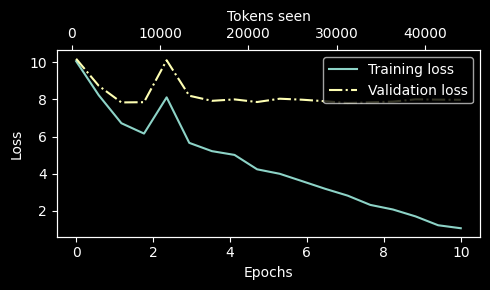

In [24]:
# 导入matplotlib的pyplot模块，用于绘图，这是Python最常用的可视化库之一
import matplotlib.pyplot as plt
# 从matplotlib的ticker模块导入MaxNLocator，作用是强制x轴刻度显示为整数
# 避免训练轮次(Epochs)出现小数刻度，让图表更易读
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


# -------------------------- 函数调用部分 --------------------------
# 生成与训练损失长度对应的轮次张量，用于x轴刻度
# torch.linspace(start, end, steps)：生成从start到end的steps个等间距数值
# 这里从0到num_epochs（总训练轮次），生成len(train_losses)个数值
# 对应每次评估损失的轮次，比如每训练1个epoch评估一次，就生成0,1,2,...num_epochs
# 若每训练0.5个epoch评估一次，就会生成0, 0.5, 1, ... 等中间值
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))

# 调用绘图函数，传入轮次、token数、训练/验证损失，绘制损失曲线
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

#### Temperature scaling

In [25]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [26]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [27]:
probas = torch.softmax(next_token_logits, dim=0)
print(probas)

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])


In [28]:
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [29]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [30]:
def print_sample_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
                for i in range(1000)]
    sample_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sample_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sample_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [31]:
# temperature scaling
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

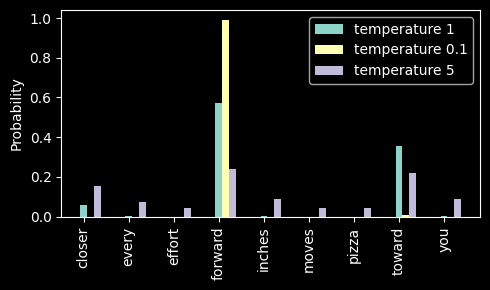

In [32]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width,
                   label=f"temperature {T}")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

#### Top-k sampling

In [33]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("top_logits", top_logits)
print("top_pos", top_pos)

top_logits tensor([6.7500, 6.2800, 4.5100])
top_pos tensor([3, 7, 0])


In [34]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print("new_logits", new_logits)

new_logits tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [35]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


####  A modified text generation function with more diversity

In [36]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    """
    GPT文本生成函数（支持温度采样、Top-K采样、提前终止）
    :param model: GPT模型
    :param idx: 输入的token索引张量 [batch_size, seq_len]
    :param max_new_tokens: 最多生成多少个token
    :param context_size: 模型最大上下文长度
    :param temperature: 温度系数（>0 采样，=0 贪心搜索）
    :param top_k: Top-K采样，保留概率最高的K个token
    :param eos_id: 结束符token，遇到则停止生成
    :return: 生成完成的完整token序列
    """
    # ===================== 核心修复：设备同步 =====================
    # 自动获取模型所在设备（CPU/GPU）
    device = next(model.parameters()).device
    # 将输入token移动到模型所在设备，解决跨设备报错
    idx = idx.to(device)
    # =============================================================

    # 循环生成新token
    for _ in range(max_new_tokens):
        # 截取最后 context_size 个token作为模型输入（防止超过上下文限制）
        idx_cond = idx[:, -context_size:]

        # 禁用梯度计算（推理阶段不需要更新参数）
        with torch.no_grad():
            logits = model(idx_cond)

        # 只取最后一个位置的输出（预测下一个token）
        logits = logits[:, -1, :]

        # ===================== Top-K 采样 =====================
        if top_k is not None:
            # 获取概率最高的top_k个logit
            top_logits, _ = torch.topk(logits, top_k)
            # 找到top_k中的最小阈值
            min_val = top_logits[:, -1]
            # 把低于阈值的logit设为负无穷（softmax后概率为0）
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),  # 设备同步
                logits
            )

        # ===================== 温度缩放 + 采样 =====================
        if temperature > 0.0:
            # 温度缩放：控制生成多样性
            logits = logits / temperature
            # 转换为概率分布
            probs = torch.softmax(logits, dim=-1)
            # 多项式采样（随机采样，更有创意）
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # 贪心搜索：直接选概率最高的token（最稳定、最保守）
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # ===================== 提前终止（修复bug） =====================
        if eos_id is not None and idx_next.item() == eos_id:
            break

        # 将新生成的token拼接到原序列后面
        idx = torch.cat((idx, idx_next), dim=1)

    # 返回完整的token序列
    return idx

In [37]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you was just lay his pictures--itels I didn't let. . .


#### Loading and saving model weights in PyTorch

In [38]:
torch.save(model.state_dict(), "model.pth")

In [39]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [40]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()},
    "model_and_optimizer.pth")

In [41]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

### Loading pretrained weights from OpenAI

In [45]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1b6fadba350>)

In [46]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
     model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [47]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [48]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [49]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [50]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [51]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [52]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(
            f"Shape mismatch: {left.shape} != {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

####  Loading OpenAI weights into our GPT model code

In [53]:
import numpy as np


def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
         q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
         gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
         gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
         gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
         q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
         gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
         gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
         gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
         gpt.trf_blocks[b].att.out_proj.weight = assign(
                gpt.trf_blocks[b].att.out_proj.weight,
                params["blocks"][b]["attn"]["c_proj"]["w"].T)
         gpt.trf_blocks[b].att.out_proj.bias = assign(
         gpt.trf_blocks[b].att.out_proj.bias,
         params["blocks"][b]["attn"]["c_proj"]["b"])
         gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
         gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
         gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
         gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
         gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
         gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
         gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
         gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


In [54]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [62]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=34,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.2
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the eye can see. (That's because you're only going to see it at those locations where you'd typically not see a lens on a subject)
